# Regresión Logística
Predicción de ataques cardiaco

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
datos=pd.read_csv("heart_attack.csv")

In [3]:
datos.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa,output
0,63,1,3,145,233,1,0,150,0,0,1
1,37,1,2,130,250,0,1,187,0,0,1
2,41,0,1,130,204,0,0,172,0,0,1
3,56,1,1,120,236,0,1,178,0,0,1
4,57,0,0,120,354,0,1,163,1,0,1


In [4]:
#Seleccionamos, por ahora, solo algunos atributos
X=datos[["age","trtbps","chol", "thalachh"]]
#Seleccionamos el target
y=datos["output"]

In [5]:
modelo=LogisticRegression()
# Construimos los conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.80,random_state=1234)
#entrenamos el modelo
modelo.fit(X_train,y_train)

LogisticRegression()

In [6]:
# Hacemos las predicciones
y_pred=modelo.predict(X_test)

In [7]:
y_pred

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0], dtype=int64)

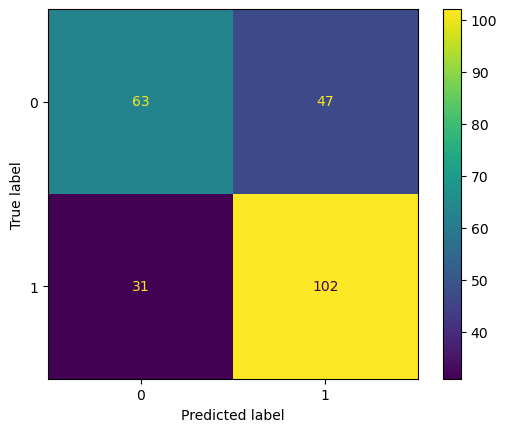

In [8]:
mat_confusion=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(mat_confusion).plot()

El modelo se probó con 110 pacientes de bajo riesgo (0) y 133 pacientes del alto riesgo (1).
De los 243 pacientes, en el conjunto de prueba, El modelo predice 94 pacientes de bajo riesgo (0) y
149 pacientes de algo riesgo (1).

Observamos que 63+102 pacientes fueron clasificados correctamente. 

La **exactitud** es la proporción de pacientes que son clasificadas correctamente.
En este caso, la exactitud es 0.679. Esto se interpreta como: "El modelo clasifica correctamente el 67.9% de los datos"

La **precisión** Es el porcentaje de valores postivos (1's) predichos correctamente por el modelo. 
En esta caso, la precisión es (Número de valores predichos positivos correctos / Número de valores predichos positivos) 
En este caso la precisión es 102 / (47+102)  = 0.6845. " Cuando el modelo predice 1, la probabilidad de que realmente 
sea un 1 es 0.6845. 

La **sensibilidad** Es la proporción de valores predichos por la prueba correctamente dentro de todos los casos verdaderos.
positivos.
En este caso, la sensibilidad es  102/ (102+31)  = 0.7679.
Si un paciente es de alto riesgo, es decir es un 1, la sensibilidad es la probabilidad de que la prueba lo clasifique como un 1. 

La **especificidad** es la proporción de valores predichos correctamente por la prueba dentro de todos los casos verdaderos negativos (0s). 
En este caso, la especificidad es: 63 / (63+47)=0.5727.
El 57.27% de los pacientes que son de bajo riesgo, son predichos de bajo ries por el modelo. 


La **razón de valores falsos positivos (FPR)** Es la proporción de valores predichos por la prueba como positivos pero que en realidad son negativos. 
FPR = 47/(63+47)  =   1- especificidad

La **razón de valores falsos negativo (FNR)** Es la proporción de valores predichos por la prueba como negativos pero que en realidad son positivos. 

FNR = 31/(31+102) = 1- sensibilidad.  

In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.67      0.57      0.62       110
           1       0.68      0.77      0.72       133

    accuracy                           0.68       243
   macro avg       0.68      0.67      0.67       243
weighted avg       0.68      0.68      0.68       243



In [10]:
# IMPORTANTE: El modelo de regresión logística devuelve una probabilidad, P(Y=1). Usualmente para la predicciones 
# se procede como sigue: si P(Y=1)>=0.5 entonces el modelo predice 1. Por otro lado, si P(Y=1)<0.5, entonces el modelo
# predice 0.

# Para ver estas probabilidades
modelo.predict_proba(X_test)[:,1]  # <--- Probabilidad de que la i-esima observación en el conjunto de prueba sea un 1.


array([0.75025113, 0.58820483, 0.85483984, 0.50683901, 0.55624988,
       0.56906888, 0.28115103, 0.87746242, 0.67485529, 0.79126284,
       0.80797184, 0.31239444, 0.43915774, 0.9183716 , 0.23316528,
       0.09346743, 0.60279177, 0.77505399, 0.60801856, 0.86472219,
       0.87507786, 0.89378336, 0.13111589, 0.23160393, 0.70507726,
       0.58963926, 0.70541956, 0.57428866, 0.7669417 , 0.57013036,
       0.8722346 , 0.93301818, 0.59721225, 0.21043275, 0.17702026,
       0.22082519, 0.56974902, 0.74305   , 0.87282923, 0.87446494,
       0.33692195, 0.12296066, 0.6973049 , 0.48971197, 0.91201559,
       0.29914661, 0.65152965, 0.29230604, 0.0958941 , 0.57097622,
       0.73364612, 0.49970671, 0.8577024 , 0.51940775, 0.63433407,
       0.86874737, 0.85483984, 0.56516987, 0.14722363, 0.41185095,
       0.65660698, 0.3485744 , 0.34557572, 0.30525611, 0.36065463,
       0.67608059, 0.96448402, 0.83109292, 0.65258686, 0.94426539,
       0.56869128, 0.63777261, 0.69474685, 0.94205217, 0.62846

In [11]:
modelo.predict_proba(X_test)[:,0]  # <--- Probabilidad de que la i-esima observación en el conjunto de prueba sea un 0.


array([0.24974887, 0.41179517, 0.14516016, 0.49316099, 0.44375012,
       0.43093112, 0.71884897, 0.12253758, 0.32514471, 0.20873716,
       0.19202816, 0.68760556, 0.56084226, 0.0816284 , 0.76683472,
       0.90653257, 0.39720823, 0.22494601, 0.39198144, 0.13527781,
       0.12492214, 0.10621664, 0.86888411, 0.76839607, 0.29492274,
       0.41036074, 0.29458044, 0.42571134, 0.2330583 , 0.42986964,
       0.1277654 , 0.06698182, 0.40278775, 0.78956725, 0.82297974,
       0.77917481, 0.43025098, 0.25695   , 0.12717077, 0.12553506,
       0.66307805, 0.87703934, 0.3026951 , 0.51028803, 0.08798441,
       0.70085339, 0.34847035, 0.70769396, 0.9041059 , 0.42902378,
       0.26635388, 0.50029329, 0.1422976 , 0.48059225, 0.36566593,
       0.13125263, 0.14516016, 0.43483013, 0.85277637, 0.58814905,
       0.34339302, 0.6514256 , 0.65442428, 0.69474389, 0.63934537,
       0.32391941, 0.03551598, 0.16890708, 0.34741314, 0.05573461,
       0.43130872, 0.36222739, 0.30525315, 0.05794783, 0.37153

In [12]:
# La probabilidad la podemos emplear para mejorar el desempeño del modelo en algunas métricas, como la sensibilidad
# y la especificidad.

y_pred_proba=modelo.predict_proba(X_test)[:,1]
y_pred_proba   # <- Probabilidad de "éxito"

 

array([0.75025113, 0.58820483, 0.85483984, 0.50683901, 0.55624988,
       0.56906888, 0.28115103, 0.87746242, 0.67485529, 0.79126284,
       0.80797184, 0.31239444, 0.43915774, 0.9183716 , 0.23316528,
       0.09346743, 0.60279177, 0.77505399, 0.60801856, 0.86472219,
       0.87507786, 0.89378336, 0.13111589, 0.23160393, 0.70507726,
       0.58963926, 0.70541956, 0.57428866, 0.7669417 , 0.57013036,
       0.8722346 , 0.93301818, 0.59721225, 0.21043275, 0.17702026,
       0.22082519, 0.56974902, 0.74305   , 0.87282923, 0.87446494,
       0.33692195, 0.12296066, 0.6973049 , 0.48971197, 0.91201559,
       0.29914661, 0.65152965, 0.29230604, 0.0958941 , 0.57097622,
       0.73364612, 0.49970671, 0.8577024 , 0.51940775, 0.63433407,
       0.86874737, 0.85483984, 0.56516987, 0.14722363, 0.41185095,
       0.65660698, 0.3485744 , 0.34557572, 0.30525611, 0.36065463,
       0.67608059, 0.96448402, 0.83109292, 0.65258686, 0.94426539,
       0.56869128, 0.63777261, 0.69474685, 0.94205217, 0.62846

In [13]:
cut_off=0.2 # <- Punto de corte.
y_pred=np.where(y_pred_proba>=cut_off,1,0)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.18      0.29       110
           1       0.58      0.93      0.71       133

    accuracy                           0.59       243
   macro avg       0.63      0.56      0.50       243
weighted avg       0.63      0.59      0.52       243



In [14]:
# La métrica que hemos obtenido, depende del conjunto de prueba y entrenamiento.
# Para que no dependan, hacemos una validación cruzada.

modelo=LogisticRegression()
scores= cross_val_score(modelo,X,y,scoring="recall",cv=10,n_jobs=-1)
print("La sensibilidad promedio del modelo es: {:.3f}".format(scores.mean()))


La sensibilidad promedio del modelo es: 0.768


In [15]:
# Modelo final, tendría una sensibilidad promedio del 76.8%. 
# Entrenamos el modelo final, empleando TODOS los datos.

In [16]:
modelo.fit(X,y)

LogisticRegression()

In [17]:
# Datos nuevos...
# ¿ Qué tan bien predice el modelo a los datos con los que lo estimamos? 
y_pred=modelo.predict(X)
print(classification_report(y,y_pred))
# Esta es una métrica optimista

              precision    recall  f1-score   support

           0       0.70      0.64      0.67       138
           1       0.72      0.78      0.75       165

    accuracy                           0.71       303
   macro avg       0.71      0.71      0.71       303
weighted avg       0.71      0.71      0.71       303



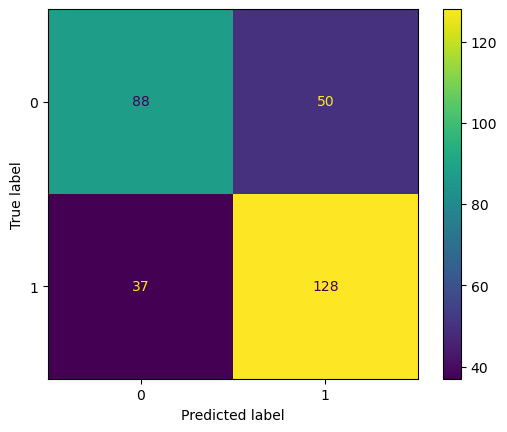

In [18]:
mat_confusion=confusion_matrix(y,y_pred)
ConfusionMatrixDisplay(mat_confusion).plot()

In [19]:
modelo.coef_.reshape(4,1)

array([[-0.00539038],
       [-0.01566433],
       [-0.0030622 ],
       [ 0.04361989]])

In [20]:
X.columns

Index(['age', 'trtbps', 'chol', 'thalachh'], dtype='object')

In [21]:
resultados=pd.DataFrame()
resultados["Coeficientes"]=X.columns
resultados["Valores"]=modelo.coef_.reshape(4,1)
resultados["Exp_coeficientes"]=np.exp(modelo.coef_.reshape(4,1))
resultados

,Coeficientes,Valores,Exp_coeficientes
0,age,-0.005390,0.994624
1,trtbps,-0.015664,0.984458
2,chol,-0.003062,0.996942
3,thalachh,0.043620,1.044585


In [22]:
np.exp(0.043620)

1.0445853370317564

In [23]:
# edad: age, el coeficiente es 
np.exp(-0.005390)

0.99462449998666

OR(edad+1) = 0.9946*OR(edad).
OddRatio = razón de ser paciente de alto riesgo comparado con la de bajo riesgo.
Esta razón, casi no se modifica con la edad. Dos pacientes que tienen la misma presión arterial,
el mismo nivel de colesterol y la máxima frecuencia cardiaca, pero uno es un año más grande 
que otro, el modelo me dice que el OR es el mismo para los dos.  

# Inclusión de las variables categóricas

In [24]:
# Vamos a incluir una variable categórica: cp
#Atributos
X=datos[["age","trtbps","chol", "thalachh","cp"]]
#target
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: output, Length: 303, dtype: int64

In [25]:
X

,age,trtbps,chol,thalachh,cp
0,63,145,233,150,3
1,37,130,250,187,2
2,41,130,204,172,1
3,56,120,236,178,1
4,57,120,354,163,0
...,...,...,...,...,...
298,57,140,241,123,0
299,45,110,264,132,3
300,68,144,193,141,0
301,57,130,131,115,0


In [26]:
# Vamos a crear las variables dummies para cp
X=pd.get_dummies(X, columns=["cp"], drop_first=True)
# La cetegoria de referencia es el dolor tipo 0. Típíco de angina
X

,age,trtbps,chol,thalachh,cp_1,cp_2,cp_3
0,63,145,233,150,0,0,1
1,37,130,250,187,0,1,0
2,41,130,204,172,1,0,0
3,56,120,236,178,1,0,0
4,57,120,354,163,0,0,0
...,...,...,...,...,...,...,...
298,57,140,241,123,0,0,0
299,45,110,264,132,0,0,1
300,68,144,193,141,0,0,0
301,57,130,131,115,0,0,0


In [27]:
modelo=LogisticRegression(max_iter=1000)
scores=cross_val_score(modelo, X,y, scoring="recall",cv=10,n_jobs=-1)
print("La sensibilidad promedio es:{:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es:0.768 +/- 0.079


In [28]:
#El modelo validado, lo entrenamos empleando todos los datos
modelo.fit(X,y)

LogisticRegression(max_iter=1000)

In [29]:
resultados=pd.DataFrame()
resultados["Coeficientes"]=X.columns
resultados["Valores"]=modelo.coef_.reshape(7,1)
resultados["Exp_coeficientes"]=np.exp(modelo.coef_.reshape(7,1))
resultados

,Coeficientes,Valores,Exp_coeficientes
0,age,-0.008313,0.991721
1,trtbps,-0.017293,0.982856
2,chol,-0.002465,0.997538
3,thalachh,0.033590,1.034161
4,cp_1,1.580023,4.855067
5,cp_2,1.763229,5.831237
6,cp_3,1.251398,3.495227


**caso 1:** Si el paciente tiene dolor de pecho (cp) tipo 1.
OR(paciente con cp=1) = 4.85 * OR(paciente con cp=0)

**caso 2:** Si el paciente tiene dolor de pecho (cp) tipo 2.
OR(paciente con cp=2) = 5.8 * OR(paciente con cp=0)

**caso 3:** Si el paciente tiene dolor de pecho (cp) tipo 3.
OR(paciente con cp=3) = 3.5 * OR(paciente con cp=0)

In [30]:
# Incluyamos el género
# Vamos a incluir una variable categórica: cp
#Atributos
X=datos[["age","trtbps","chol", "thalachh","cp", "sex"]]
#target
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: output, Length: 303, dtype: int64

In [31]:
# Vamos a crear las variables dummies para cp
X=pd.get_dummies(X, columns=["cp","sex"], drop_first=True)
# La cetegoria de referencia es el dolor tipo 0. Típíco de angina
# Para sexo, la referencia son los hombres

In [32]:
X

,age,trtbps,chol,thalachh,cp_1,cp_2,cp_3,sex_1
0,63,145,233,150,0,0,1,1
1,37,130,250,187,0,1,0,1
2,41,130,204,172,1,0,0,0
3,56,120,236,178,1,0,0,1
4,57,120,354,163,0,0,0,0
...,...,...,...,...,...,...,...,...
298,57,140,241,123,0,0,0,0
299,45,110,264,132,0,0,1,1
300,68,144,193,141,0,0,0,1
301,57,130,131,115,0,0,0,1


In [33]:
modelo=LogisticRegression(max_iter=1000)
scores=cross_val_score(modelo, X,y, scoring="recall",cv=10,n_jobs=-1)
print("La sensibilidad promedio es:{:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es:0.835 +/- 0.074


In [34]:
#El modelo validado, lo entrenamos empleando todos los datos
modelo.fit(X,y)
resultados=pd.DataFrame()
resultados["Coeficientes"]=X.columns
resultados["Valores"]=modelo.coef_.reshape(8,1)
resultados["Exp_coeficientes"]=np.exp(modelo.coef_.reshape(8,1))
resultados

,Coeficientes,Valores,Exp_coeficientes
0,age,-0.017000,0.983144
1,trtbps,-0.020306,0.979899
2,chol,-0.005881,0.994136
3,thalachh,0.038052,1.038786
4,cp_1,1.600911,4.957545
5,cp_2,1.716076,5.562658
6,cp_3,1.470757,4.352527
7,sex_1,-1.695728,0.183466


**caso, sexo =1** Comparamos el OR de un hombre y una mujer con las mismas características,
OR(sex=1)=0.1834* OR(sex=0), de otro modo. OR(sex=0) = 5.4525* OR(sex=1). 
El OR para un hombre es 5.5 vaces más alto que el de una mujer.

In [35]:
# Incluimos todas las variables
X=datos[["age","sex","cp","trtbps","chol","fbs","restecg","thalachh","exng","caa"]]
y=datos["output"]

In [36]:
X=pd.get_dummies(X, columns=["sex","cp","fbs","restecg","exng"], drop_first=True)
X

,age,trtbps,chol,thalachh,caa,sex_1,cp_1,cp_2,cp_3,fbs_1,restecg_1,restecg_2,exng_1
0,63,145,233,150,0,1,0,0,1,1,0,0,0
1,37,130,250,187,0,1,0,1,0,0,1,0,0
2,41,130,204,172,0,0,1,0,0,0,0,0,0
3,56,120,236,178,0,1,1,0,0,0,1,0,0
4,57,120,354,163,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0,0,0,0,0,0,1,0,1
299,45,110,264,132,0,1,0,0,1,0,1,0,0
300,68,144,193,141,2,1,0,0,0,1,1,0,0
301,57,130,131,115,1,1,0,0,0,0,1,0,1


In [37]:
#Validamos el modelos
modelo=LogisticRegression(max_iter=1000)
scores=cross_val_score(modelo, X,y, scoring="recall",cv=10,n_jobs=-1)
print("La sensibilidad promedio es:{:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es:0.852 +/- 0.103


In [38]:
modelo.fit(X,y)

LogisticRegression(max_iter=1000)

In [39]:
resultados=pd.DataFrame()
resultados["Coeficientes"]=X.columns
resultados["Valores"]=modelo.coef_.reshape(13,1)
resultados["Exp_coeficientes"]=np.exp(modelo.coef_.reshape(13,1))
resultados

,Coeficientes,Valores,Exp_coeficientes
0,age,-0.000174,0.999826
1,trtbps,-0.017770,0.982387
2,chol,-0.005559,0.994456
3,thalachh,0.033077,1.033630
4,caa,-0.744793,0.474833
5,sex_1,-1.564118,0.209273
6,cp_1,1.176657,3.243514
7,cp_2,1.463623,4.321587
8,cp_3,1.111263,3.038194
9,fbs_1,0.182321,1.199999


OR(exng=1) = 0.349344 * OR(exgn=0)   ->  OR(exgn=0) = 2.85*OR(exgn=1) 

In [40]:
X

,age,trtbps,chol,thalachh,caa,sex_1,cp_1,cp_2,cp_3,fbs_1,restecg_1,restecg_2,exng_1
0,63,145,233,150,0,1,0,0,1,1,0,0,0
1,37,130,250,187,0,1,0,1,0,0,1,0,0
2,41,130,204,172,0,0,1,0,0,0,0,0,0
3,56,120,236,178,0,1,1,0,0,0,1,0,0
4,57,120,354,163,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0,0,0,0,0,0,1,0,1
299,45,110,264,132,0,1,0,0,1,0,1,0,0
300,68,144,193,141,2,1,0,0,0,1,1,0,0
301,57,130,131,115,1,1,0,0,0,0,1,0,1


# Podemos "comprobar" que el modelo clasifica como lo predecimos

Observamos que el modelo tenia una sensibilidad casi del 85%. ¿ En datos nuevos
el modelo predice con este nivel de sensibilidad?. Si nuestro modelo no está sobreajustado, esperamos que la sensibilidad esté alrededor del 85%.

Hagamos una prueba:
1.- Vamos a partir el conjunto de datos entres partes. el 20% los vamos a poner de datos nuevos.
2.- El 80% restante lo vamos dividir en 2 partes: el 80% para entrenar y el 20% para prueba 
    (el paso 2 es el problema de la selección del modelo) 
3.- Entrenamos el modelo con el conjunto de entrenamiento y validamos en el 20%. Obtenemos una métrica de desempeño para el modelo.
4.- Voy a hacer la predicciones con los datos nuevos (paso 1) utilizando el modelo entrenado en     (paso 3), comprobamos si las métricas son similares...

In [41]:
# Atributos
X=X[["age","trtbps","chol","thalachh","caa","sex_1","cp_1","cp_2","cp_3","fbs_1","restecg_1","restecg_2","exng_1"]]
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: output, Length: 303, dtype: int64

In [42]:
# Paso 1. 20% de los datos los vamos a guardar como datos nuevos
X_val,X_nuevos,y_val,y_nuevos=train_test_split(X,y,test_size=0.20,random_state=1234,stratify=y)
# Paso 2. Divir al conjunto del 80% restante, en este caso X_val, y_val <- Todos los datos
X_train, X_test, y_train, y_test = train_test_split(X_val,y_val, random_state=1234, stratify=y_val)

In [43]:
#Validamos el modelos
modelo=LogisticRegression(max_iter=1000)
scores=cross_val_score(modelo, X_val,y_val, scoring="recall",cv=10,n_jobs=-1)
print("La sensibilidad promedio es:{:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es:0.834 +/- 0.118


La sensibilidad obtenida es 
"La sensibilidad promedio es:0.834 +/- 0.118"

Será así en los datos nuevos?

In [44]:
#Entrenamos el modelo empleando todos los datos
modelo.fit(X_val,y_val)

LogisticRegression(max_iter=1000)

In [45]:
y_pred=modelo.predict(X_nuevos)  # Estos datos no los ha visto el modelo

In [46]:
print(classification_report(y_nuevos, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86        28
           1       0.82      1.00      0.90        33

    accuracy                           0.89        61
   macro avg       0.91      0.88      0.88        61
weighted avg       0.91      0.89      0.88        61



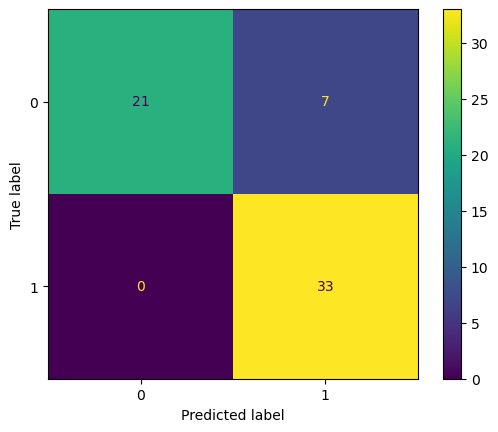

In [47]:
mat_confusion=confusion_matrix(y_nuevos,y_pred)
ConfusionMatrixDisplay(mat_confusion).plot()

Esta mètrica depende del conjunto que elegimos para entrenar y el que elegimos como datos "nuevos". Para que no dependa de estos conjuntos, hacemos una validaciòn cruzada anidada.


In [48]:

from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV

espacio_param ={"C":[1]}

# Definir el esquema de validaciòn cruzada exterior:  Como dividimos el conjunto de datos en 
#                                                      datos de validación y datos nuevos  
                                                    
val_exterior=RepeatedKFold(n_repeats=10, n_splits=5)

# Definir el esquema de validaciòn cruzada interior  #(Cómo dividimos el conjunto de validación)
val_interior=KFold(n_splits=10)

#definimos el modelo
modelo=LogisticRegression()
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="recall", cv=val_interior, n_jobs=-1)
scores = cross_val_score(modelo_candidato,X,y,scoring="recall",cv=val_exterior, n_jobs=-1)
print("La sensibilidad promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es 0.845 +/- 0.056


In [49]:
# Esta sensibilidad del 84% es en datos que el modelo nunca vio....

# Regularización en regresión logística

1. Eliminar las unidades de medición de los atributos
2. Hacer la validación cruzada para medir el desempeño predictivo del modelo.
3. Ojo: con la fuga información... 
4. Calibrar el mejor valor de C. 

In [50]:
# Mecanismo para eliminar las unidades de medición 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline

# espacio de parámetros: Conjunto de posibles valoreas del hiperparámetro C
espacio_param={"logisticregression__C":[0.01,0.1,0.2,0.5,1,1.5,2.0,5]}
modelo=make_pipeline(MinMaxScaler(), LogisticRegression())
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="recall", cv=10,n_jobs=-1)
modelo_candidato.fit(X,y)
print("La mejor configuración de hiperparámetros: ", modelo_candidato.best_params_ )
print("La mejor métrica es: ", modelo_candidato.best_score_ )

La mejor configuración de hiperparámetros:  {'logisticregression__C': 0.01}
La mejor métrica es:  0.9577205882352942


In [51]:
# En esta etapa solo resolvimos el problema de seleccionar el modelo
# El modelo final es:
modelo_final=LogisticRegression(C=0.01)
# Antes de estimar y hacer predicciones, vamos a obtener una métrica más "realista" del desempeño
# predictivo del modelo que hemos calibrado, empleando una validación cruzada anidada.

In [52]:
# Validación cruzada anidada.

# espacio de parámetros: Conjunto de posibles valoreas del hiperparámetro C
espacio_param={"logisticregression__C":[0.01,0.1,0.2,0.5,1,1.5,2.0,5]}
# Definimos el modelo
modelo=make_pipeline(MinMaxScaler(), LogisticRegression())
# Definimos los dos diseños de validación 
val_exterior=RepeatedKFold(n_repeats=10, n_splits=5)
val_interior=KFold(n_splits=10)
# En esta linea ajustamos todos los modelos, uno para cada valor de C
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="recall",cv= val_interior,n_jobs=-1)
scores=cross_val_score(modelo_candidato,X,y,scoring="recall",cv=val_exterior,n_jobs=-1)
print("La sensibilidad promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es 0.899 +/- 0.080


In [53]:
# Cómo hacemos las predicciones... 
modelo_final=LogisticRegression(C=0.01)
# Lo tenemos que entrenar empleando TODOS los datos, pero OJO, los datos tienen
# que estar reescalados
escala=MinMaxScaler()
X_std=escala.fit_transform(X)
modelo_final.fit(X_std,y)  # >-Modelo final entrenado

LogisticRegression(C=0.01)

In [54]:
# Datos nuevos
X_nuevos=pd.DataFrame({"age":[70],"trtbps":[145],"chol":[250],"thalachh":[125],"caa":[4],
                      "sex_1":[0],"cp_1":[0],"cp_2":[1],"cp_3":[0],"fbs_1":[1],
                      "restecg_1":[0],"restecg_2":[1],"exng_1":[0]})
X_nuevos


,age,trtbps,chol,thalachh,caa,sex_1,cp_1,cp_2,cp_3,fbs_1,restecg_1,restecg_2,exng_1
0,70,145,250,125,4,0,0,1,0,1,0,1,0


In [55]:
#Tenemos que reescalar los datos
X_nuevos_std=escala.transform(X_nuevos)
X_nuevos_std

array([[0.85416667, 0.48113208, 0.28310502, 0.41221374, 1.        ,
        0.        , 0.        , 1.        , 0.        , 1.        ,
        0.        , 1.        , 0.        ]])

In [56]:
modelo_final.predict(X_nuevos_std)

array([1], dtype=int64)

In [57]:
# Con una sensibilidad del 89%

# Una segunda aproximación para mejorar la tarea predictiva del modelo

In [58]:
# Mejora 1. Vamos a emplear OneHotEnconder, para crear la dummies
# Mejora 2. Intercambiar MinMaxScaler con Standardscaler
datos=pd.read_csv("heart_attack.csv")


In [61]:
datos
y=datos["output"]
del datos["output"]
X=datos

In [86]:
# Crear las dummies
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

# Definir las operaciones que se van a aplicar sobre qué columnas

trans_column=make_column_transformer((OneHotEncoder(drop="first"),["sex","cp","fbs","restecg","exng"]),
                                     (MinMaxScaler(),["age","trtbps","chol","thalachh","caa"]),
                                    remainder="passthrough")

# Hacer la validación cruzada
pipe=make_pipeline(trans_column,LogisticRegression(max_iter=1000))
scores=cross_val_score(pipe, X,y, scoring="recall",cv=10,n_jobs=-1)
print("La sensibilidad promedio es:{:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es:0.822 +/- 0.084


Con el StandardScaler logramos La sensibilidad promedio es:0.852 +/- 0.103
Con el MinMaxScaler logramos La sensibilidad promedio es:0.822 +/- 0.084


# Regularizar el modelo, y hacer una calibración del modelo

In [82]:
# espacio de parámetros: Conjunto de posibles valoreas del hiperparámetro C
espacio_param={"logisticregression__C":[0.01,0.1,0.2,0.5,1,1.5,2.0,5]}
modelo=make_pipeline(trans_column, LogisticRegression(max_iter=1000))
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="recall", cv=10,n_jobs=-1)
modelo_candidato.fit(X,y)
print("La mejor configuración de hiperparámetros: ", modelo_candidato.best_params_ )
print("La mejor métrica es: ", modelo_candidato.best_score_ )

La mejor configuración de hiperparámetros:  {'logisticregression__C': 0.01}
La mejor métrica es:  0.9577205882352942


In [78]:
## Obtengo el mejor modelo... y ese mejor modelo es:
mejor_modelo=LogisticRegression(C=0.01, max_iter=1000)
# Hace falta medir el desempeño predictivo del mejor_modelo utilizando datos nuevos.

In [87]:
# Validación cruzada anidada.

# espacio de parámetros: Conjunto de posibles valoreas del hiperparámetro C
espacio_param={"logisticregression__C":[0.01,0.1,0.2,0.5,1,1.5,2.0,5]}
# Definimos el modelo
modelo=make_pipeline(trans_column, LogisticRegression(max_iter=1000))
# Definimos los dos diseños de validación 
val_exterior=RepeatedKFold(n_repeats=10, n_splits=5)
val_interior=KFold(n_splits=10)
# En esta linea ajustamos todos los modelos, uno para cada valor de C
modelo_candidato=GridSearchCV(modelo, param_grid=espacio_param, scoring="recall",cv= val_interior,n_jobs=-1)
scores=cross_val_score(modelo_candidato,X,y,scoring="recall",cv=val_exterior,n_jobs=-1)
print("La sensibilidad promedio es {:.3f} +/- {:.3f}".format(scores.mean(), scores.std()))

La sensibilidad promedio es 0.889 +/- 0.088


In [ ]:
# Esta métrica es más realista, porque mide el desempeño del modelo estimado en datos que no
# ha visto.
# Con MinMaxScaler : La sensibilidad promedio es 0.889 +/- 0.083
# Con StandardScaler : La sensibilidad promedio es 0.851 +/- 0.052

In [90]:
# Ya tenemos una calificación más realista del mejor_modelo...
# Vamos a entrenar el mejor modelo empleando TODOS los datos, pero antes los tenemos que reescalar
# y recodificar
X_trans= trans_column.fit_transform(X)
mejor_modelo.fit(X_trans,y)

LogisticRegression(C=0.2, max_iter=1000)

In [91]:
X.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'caa'],
      dtype='object')

In [95]:
# Hacemos las predicciones
# Datos nuevos
X_nuevos=pd.DataFrame({"age":[70],"sex":[0],"cp":[2],"trtbps":[145],"chol":[125],
                      "fbs":[1],"restecg":[1],"thalachh":[1],"exng":[0],"caa":[3]})
X_nuevos


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,caa
0,70,0,2,145,125,1,1,1,0,3


In [96]:
x_nuevos_trans=trans_column.transform(X_nuevos)
x_nuevos_trans

array([[ 0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         1.        ,  0.        ,  0.        ,  0.85416667,  0.48113208,
        -0.00228311, -0.53435115,  0.75      ]])

In [97]:
mejor_modelo.predict(x_nuevos_trans)

array([1], dtype=int64)

In [109]:
# Probabilidad de que el paciente sea un 1.
round(float(mejor_modelo.predict_proba(x_nuevos_trans)[:,1]),2)

0.53